In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [6]:
df = pd.read_csv('stock_data.csv', parse_dates=['Date'], index_col='Date')

df.head()

,Unnamed: 0,Open,High,Low,Close,Volume,Name
Date,,,,,,,
2006-01-03,NaN,39.69,41.22,38.79,40.91,24232729,AABA
2006-01-04,NaN,41.22,41.90,40.77,40.97,20553479,AABA
2006-01-05,NaN,40.93,41.73,40.85,41.53,12829610,AABA
2006-01-06,NaN,42.88,43.57,42.80,43.21,29422828,AABA
2006-01-09,NaN,43.10,43.66,42.82,43.42,16268338,AABA


In [7]:
df.drop(columns='Unnamed: 0', inplace=True)

df.head()

,Open,High,Low,Close,Volume,Name
Date,,,,,,
2006-01-03,39.69,41.22,38.79,40.91,24232729,AABA
2006-01-04,41.22,41.90,40.77,40.97,20553479,AABA
2006-01-05,40.93,41.73,40.85,41.53,12829610,AABA
2006-01-06,42.88,43.57,42.80,43.21,29422828,AABA
2006-01-09,43.10,43.66,42.82,43.42,16268338,AABA


Plotting High Stock Prices

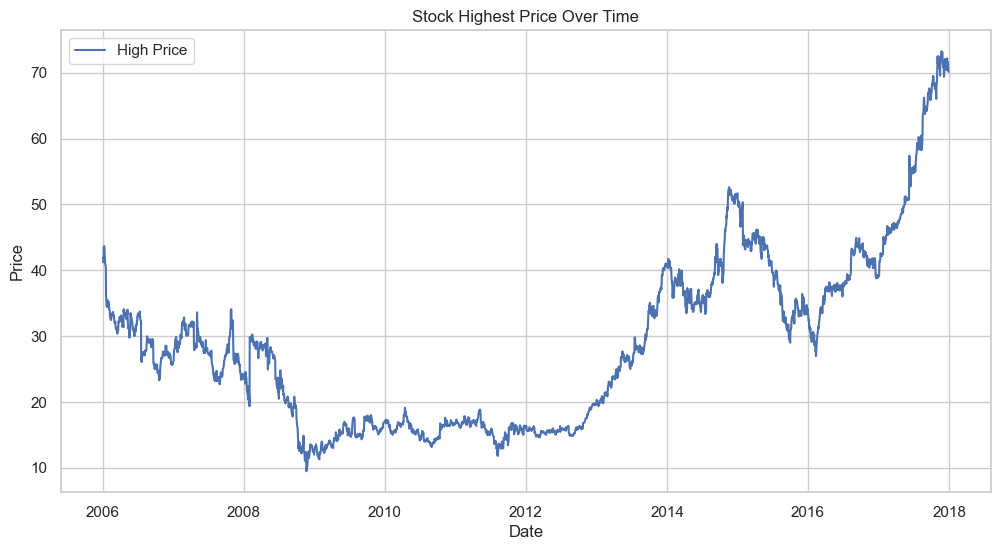

In [8]:
sns.set(style='whitegrid')

plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x=df.index, y='High', label='High Price')

plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Stock Highest Price Over Time')
plt.show()

Resampling Data

To better understand the trend of the data we will use the resampling method which provide a clearer view of trends and patterns when we are dealing with daily data.

df_resampled = df.resample('ME').mean(numeric_only=True): Resamples data to monthly frequency and calculates the mean of all numeric columns for each month.

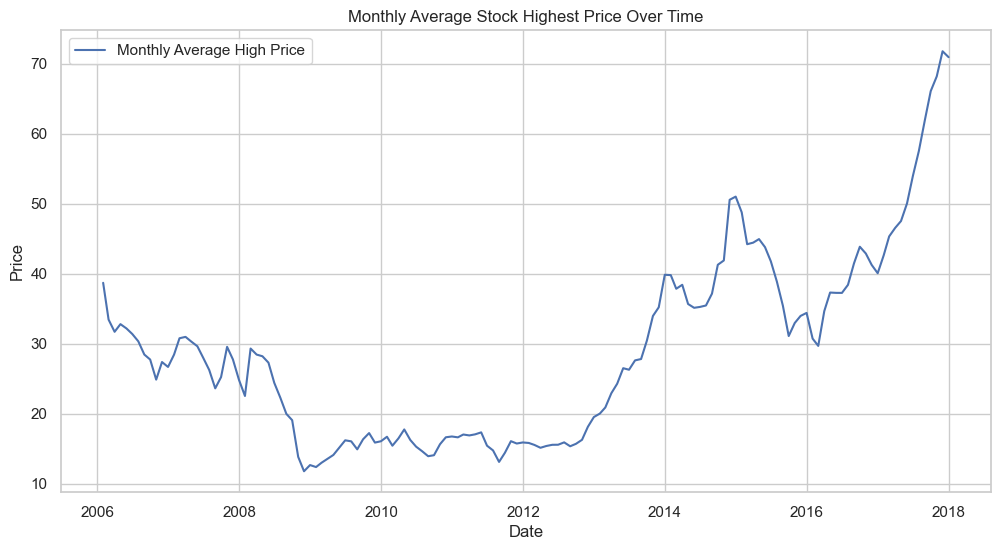

In [9]:
df_resampled = df.resample('ME').mean(numeric_only=True)

sns.set(style='whitegrid')

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_resampled, x=df_resampled.index, y='High', label='Monthly Average High Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Monthly Average Stock Highest Price Over Time')
plt.show()

Detecting Seasonality with Autocorrelation

We will detect Seasonality using the autocorrelation function (ACF) plot. Peaks at regular intervals in the ACF plot suggest the presence of seasonality.

'Date' column not found in the DataFrame.


<Figure size 1200x600 with 0 Axes>

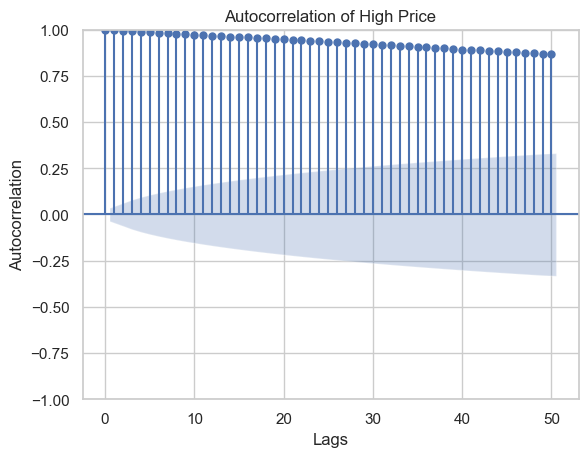

In [10]:
if 'Date' not in df.columns:
    print("'Date' column not found in the DataFrame.")
else:
    df.set_index('Date', inplace=True)

plt.figure(figsize=(12, 6))
plot_acf(df['High'], lags=50)
plt.title('Autocorrelation of High Price')
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.show()

Testing Startionary with ADF test

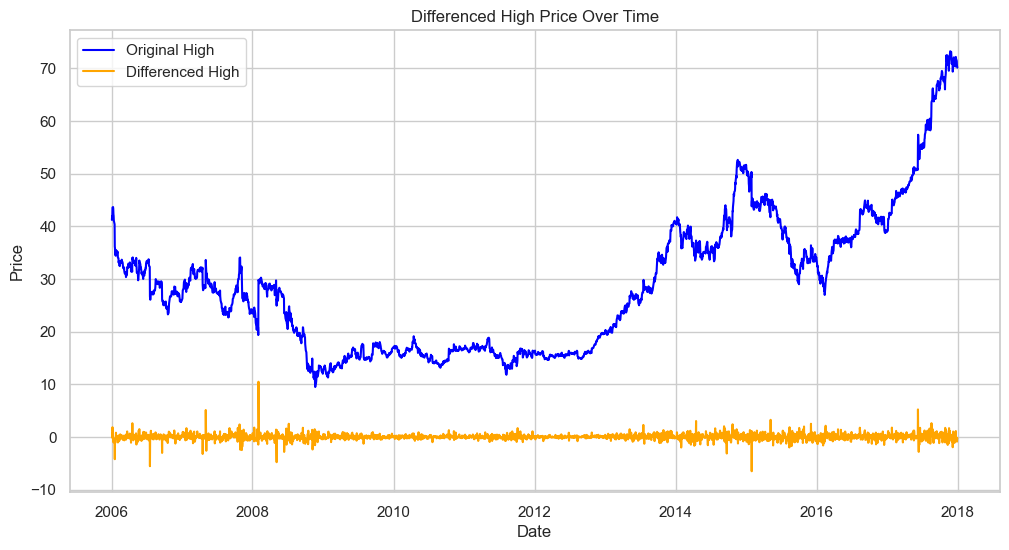

In [13]:
df['High_diff'] = df['High'].diff()
plt.figure(figsize=(12, 6))
plt.plot(df['High'], label='Original High', color='blue')
plt.plot(df['High_diff'], label='Differenced High', color='orange')
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Differenced High Price Over Time')
plt.legend()
plt.show()

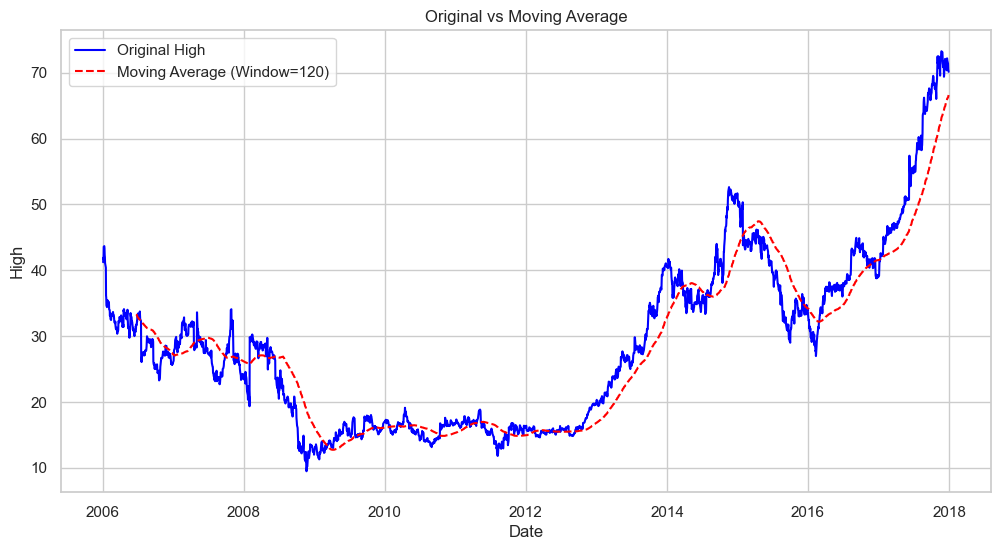

In [18]:
window_size = 120
df['high_smoothed'] = df['High'].rolling(window=window_size).mean()

plt.figure(figsize=(12, 6))

plt.plot(df['High'], label='Original High', color='blue')
plt.plot(df['high_smoothed'], label=f'Moving Average (Window={window_size})', linestyle='--', color='red')

plt.xlabel('Date')
plt.ylabel('High')
plt.title('Original vs Moving Average')
plt.legend()
plt.show()

Original Data vs. Differenced Data

In [19]:
df_combined = pd.concat([df['High'], df['High_diff']], axis=1)
print(df_combined.head())

             High  High_diff
Date                        
2006-01-03  41.22        NaN
2006-01-04  41.90       0.68
2006-01-05  41.73      -0.17
2006-01-06  43.57       1.84
2006-01-09  43.66       0.09


In [20]:
df.dropna(subset=['High_diff'], inplace=True)

df['High_diff'].head()

Date
2006-01-04    0.68
2006-01-05   -0.17
2006-01-06    1.84
2006-01-09    0.09
2006-01-10   -0.32
Name: High_diff, dtype: float64

In [21]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['High_diff'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:', result[4])

ADF Statistic: -12.14836747834325
p-value: 1.5912766134148351e-22
Critical Values: {'1%': np.float64(-3.4325316347197403), '5%': np.float64(-2.862503905260741), '10%': np.float64(-2.5672831121111113)}
